In [1]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.004                 # intervalo de muestreo: 4 ms
n  = 501                   # número de muestras
t  = np.arange(n) * dt     # eje de tiempo en segundos

print("tipo  :", type(t))
print("shape :", t.shape)
print("dtype :", t.dtype)
print("primeros 5:", t[:5])
print("último    :", t[-1], "s")

tipo  : <class 'numpy.ndarray'>
shape : (501,)
dtype : float64
primeros 5: [0.    0.004 0.008 0.012 0.016]
último    : 2.0 s


In [2]:
r = np.zeros(n)            # traza sin reflectores: 501 ceros

reflectores = [
    ("Base Terciario", 0.620,  0.18),
    ("T2 Mirador",     0.980, -0.12),
    ("K2 Gacheta",     1.340,  0.22),
]

for nombre, tiempo, rc in reflectores:
    i = int(round(tiempo / dt))
    r[i] = rc
    print(f"{nombre:16s} t={tiempo:.3f} s  ->  muestra {i:3d}   rc={rc:+.2f}")

print()
print("shape de r      :", r.shape)
print("muestras no nulas:", np.flatnonzero(r))
print("suma de r       :", r.sum())

Base Terciario   t=0.620 s  ->  muestra 155   rc=+0.18
T2 Mirador       t=0.980 s  ->  muestra 245   rc=-0.12
K2 Gacheta       t=1.340 s  ->  muestra 335   rc=+0.22

shape de r      : (501,)
muestras no nulas: [155 245 335]
suma de r       : 0.28


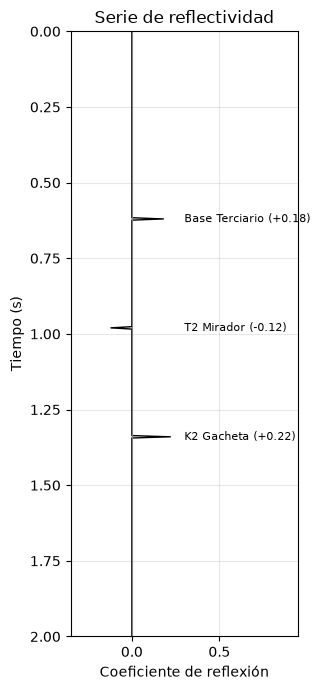

In [3]:
fig, ax = plt.subplots(figsize=(3.2, 7))

ax.plot(r, t, color="black", linewidth=1)
ax.axvline(0, color="gray", linewidth=0.8)

for nombre, tiempo, rc in reflectores:
    ax.text(0.30, tiempo, f"{nombre} ({rc:+.2f})", va="center", fontsize=8)

ax.set_xlabel("Coeficiente de reflexión")
ax.set_ylabel("Tiempo (s)")
ax.set_title("Serie de reflectividad")
ax.set_xlim(-0.35, 0.95)
ax.set_ylim(t[0], t[-1])
ax.invert_yaxis()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

muestras de la ondícula: (65,)
máximo en el índice    : 32 de 65
tiempo de ese índice   : 0.0 s


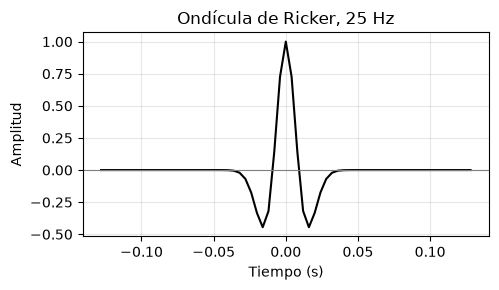

In [4]:
def ricker(f, dt, longitud=0.256):
    """Ondícula de Ricker de frecuencia dominante f (Hz)."""
    n_w = int(longitud / dt)
    if n_w % 2 == 0:
        n_w += 1                        # longitud impar: la ondícula queda centrada
    tw  = (np.arange(n_w) - n_w // 2) * dt
    arg = (np.pi * f * tw) ** 2
    w   = (1 - 2 * arg) * np.exp(-arg)
    return tw, w


tw, w = ricker(f=25, dt=dt)

print("muestras de la ondícula:", w.shape)
print("máximo en el índice    :", np.argmax(w), "de", len(w))
print("tiempo de ese índice   :", tw[np.argmax(w)], "s")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(tw, w, color="black")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.set_title("Ondícula de Ricker, 25 Hz")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

r: (501,)   w: (65,)   s: (501,)
amplitud máxima: 0.22


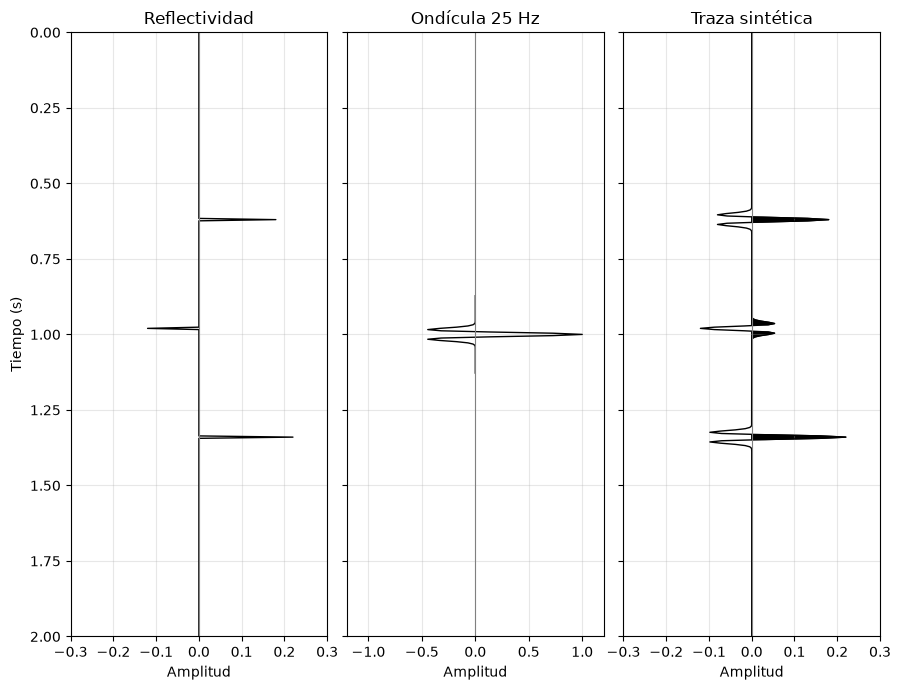

In [5]:
s = np.convolve(r, w, mode="same")

print("r:", r.shape, "  w:", w.shape, "  s:", s.shape)
print("amplitud máxima:", np.abs(s).max().round(4))

fig, axes = plt.subplots(1, 3, figsize=(9, 7), sharey=True)

axes[0].plot(r, t, color="black", lw=1)
axes[0].set_title("Reflectividad")
axes[0].set_xlim(-0.3, 0.3)

axes[1].plot(w, tw + 1.0, color="black", lw=1)
axes[1].set_title("Ondícula 25 Hz")
axes[1].set_xlim(-1.2, 1.2)

axes[2].plot(s, t, color="black", lw=1)
axes[2].fill_betweenx(t, 0, s, where=(s > 0), color="black")
axes[2].set_title("Traza sintética")
axes[2].set_xlim(-0.3, 0.3)

for ax in axes:
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("Amplitud")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Tiempo (s)")
axes[0].set_ylim(t[0], t[-1])
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()